<style>
.reveal { font-family: 'Segoe UI', system-ui, sans-serif; font-size: 1.05em; }
.reveal h2 { color: #0D2240; border-bottom: 2.5px solid #1A7A9A; padding-bottom: .3em; }
.reveal h3 { color: #1A7A9A; }
.reveal .slides section { text-align: left; }
.reveal pre { font-size: .75em; box-shadow: none; border-left: 3px solid #1A7A9A; }
.defn { background:#EAF6FA; border-left:4px solid #1A7A9A; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.nota { background:#FFF8E1; border-left:4px solid #C8961E; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.alerta { background:#FDE8E8; border-left:4px solid #C0392B; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
</style>

## CMTC: Análisis Transitorio
### T2.3 (parte a) · Modelado de Sistemas bajo Incertidumbre
Universidad de los Andes · Ingeniería Industrial

## Agenda
1. La pregunta central del análisis transitorio
2. Ecuaciones de Kolmogorov forward — derivación
3. Solución exacta: exponencial matricial
4. **Ejemplo 1:** Semáforo inteligente Carrera Séptima (derivación analítica + jmarkov)
5. Comparación: solución analítica vs ODE numérica
6. **Ejercicio 1:** Instalación con 4 máquinas y 2 técnicos
7. **Ejercicio 3:** Metro de Bogotá — 3 estaciones M/M/1/K

## Vector de estado π(t)
<div class='defn'>
El <strong>vector de probabilidades de estado</strong> es:

$$\pi(t) = [\pi_0(t), \pi_1(t), \ldots, \pi_{n-1}(t)]$$

donde πᵢ(t) = P(X(t) = i) es la probabilidad de estar en el estado i en el instante t.
</div>

**Condición inicial:** π(0) = π₀ (distribución inicial conocida)

**Normalización:** ∑ᵢ πᵢ(t) = 1 para todo t ≥ 0

## Ecuaciones de Kolmogorov hacia adelante
<div class='defn'>
Las probabilidades de estado evolucionan según:

$$\frac{d\pi(t)}{dt} = \pi(t) \cdot Q$$

o equivalentemente, para cada estado j:

$$\dot{\pi}_j(t) = \sum_{i \neq j} \pi_i(t) \, q_{ij} - \pi_j(t) \, q_j$$
</div>

**Interpretación:**
- Ganancia de probabilidad: flujo de otros estados hacia j (∑ᵢ≠ⱼ πᵢ qᵢⱼ)
- Pérdida de probabilidad: flujo saliente de j (πⱼ qⱼ)

## Solución analítica: exponencial matricial
<div class='defn'>
La solución de dπ/dt = π Q con condición inicial π(0) es:

$$\pi(t) = \pi(0) \cdot e^{Qt}$$

donde $e^{Qt} = \sum_{k=0}^{\infty} \frac{(Qt)^k}{k!}$ es la <strong>exponencial matricial</strong>.
</div>

Computacionalmente, se evalúa con `scipy.linalg.expm(Q*t)`:
```python
from scipy.linalg import expm
pi_t = pi0 @ expm(Q * t)
```

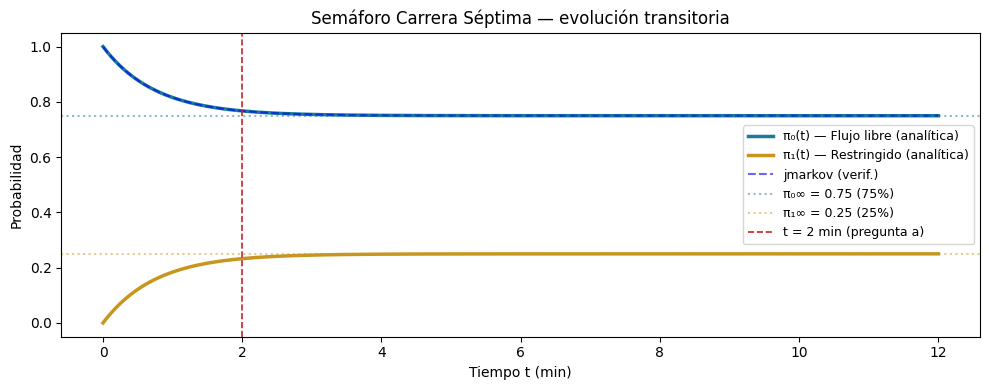

─── Respuestas ──────────────────────────────────────────────
(a) P(restringido, t=2 min):
    Analítica: π₁(2) = 1/4 - 1/4·e^(-8/3) = 0.2326 ≈ 23.3%
    jmarkov:   π₁(2) = 0.2326  ✓

(b) Largo plazo (t → ∞):
    π₀∞ = μ/(λ+μ) = 0.7500 = 75%  (flujo libre)
    π₁∞ = λ/(λ+μ) = 0.2500 = 25%  (restringido)
    jmarkov: [0.75 0.25]  ✓

Velocidad de convergencia: λ₂ = -(λ+μ) = -1.3333 min⁻¹


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# ── Semáforo Carrera Séptima ─────────────────────────────────────────
lam_s = 1/3    # min⁻¹  (libre → restringido, cada 3 min)
mu_s  = 1.0    # min⁻¹  (restringido → libre, cada 1 min)

Q_sem = np.array([[-lam_s,  lam_s],
                  [ mu_s,  -mu_s ]])
estados_sem = np.array(['Flujo libre', 'Flujo restringido'])
pi0_sem = np.array([1.0, 0.0])

# Solución analítica (2 estados)
t_arr = np.linspace(0, 12, 400)
gamma = lam_s + mu_s   # = 4/3
pi0_analitica = mu_s/gamma + lam_s/gamma * np.exp(-gamma * t_arr)
pi1_analitica = lam_s/gamma - lam_s/gamma * np.exp(-gamma * t_arr)

# Solución con jmarkov
mc_sem = ctmc(Q_sem, estados_sem)
pi_jm  = np.array([mc_sem.transient_probabilities(t, pi0_sem) for t in t_arr])
pi_inf = mc_sem.steady_state()

# Gráfica
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_arr, pi0_analitica, color='#1A7A9A', lw=2.5, label='π₀(t) — Flujo libre (analítica)')
ax.plot(t_arr, pi1_analitica, color='#C8961E', lw=2.5, label='π₁(t) — Restringido (analítica)')
ax.plot(t_arr, pi_jm[:, 0], 'b--', lw=1.5, alpha=0.6, label='jmarkov (verif.)')
ax.axhline(pi_inf[0], ls=':', color='#1A7A9A', alpha=0.5, label=f'π₀∞ = {pi_inf[0]:.2f} (75%)')
ax.axhline(pi_inf[1], ls=':', color='#C8961E', alpha=0.5, label=f'π₁∞ = {pi_inf[1]:.2f} (25%)')
ax.axvline(2, ls='--', color='#C62828', lw=1.2, label='t = 2 min (pregunta a)')
ax.set_xlabel('Tiempo t (min)'); ax.set_ylabel('Probabilidad')
ax.set_title('Semáforo Carrera Séptima — evolución transitoria')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

# Respuestas a las preguntas
pi1_t2 = lam_s/gamma - lam_s/gamma * np.exp(-gamma * 2)
pi1_jm = mc_sem.transient_probabilities(2.0, pi0_sem)[1]

print("─── Respuestas ──────────────────────────────────────────────")
print(f"(a) P(restringido, t=2 min):")
print(f"    Analítica: π₁(2) = 1/4 - 1/4·e^(-8/3) = {pi1_t2:.4f} ≈ {pi1_t2*100:.1f}%")
print(f"    jmarkov:   π₁(2) = {pi1_jm:.4f}  ✓")
print(f"\n(b) Largo plazo (t → ∞):")
print(f"    π₀∞ = μ/(λ+μ) = {mu_s/(lam_s+mu_s):.4f} = {mu_s/(lam_s+mu_s)*100:.0f}%  (flujo libre)")
print(f"    π₁∞ = λ/(λ+μ) = {lam_s/(lam_s+mu_s):.4f} = {lam_s/(lam_s+mu_s)*100:.0f}%  (restringido)")
print(f"    jmarkov: {pi_inf.round(4)}  ✓")
print(f"\nVelocidad de convergencia: λ₂ = -(λ+μ) = {-gamma:.4f} min⁻¹")

## Ejemplo 1 — Semáforo inteligente Carrera Séptima
<div class='defn'>
La Secretaría de Movilidad evalúa un semáforo en la Carrera 7ª con Calle 72. Opera en dos modos: <strong>flujo libre</strong> (estado 0) y <strong>flujo restringido</strong> (estado 1). Cambia a restringido cada 3 min en promedio (λ = 1/3 min⁻¹); vuelve a libre tras 1 min en promedio (μ = 1 min⁻¹). El sistema arranca en flujo libre.
</div>

**Preguntas:**
- **(a)** Después de 2 minutos, ¿cuál es la probabilidad de estar en modo restringido?
- **(b)** A largo plazo, ¿qué fracción del tiempo está en cada modo?

**Modelo:** Q = [[-1/3, 1/3], [1, -1]],  π(0) = (1, 0)

**Solución analítica 2 estados** (con π₀(0)=1):

$$\pi_0(t) = \frac{3}{4} + \frac{1}{4}e^{-4t/3}, \qquad \pi_1(t) = \frac{1}{4} - \frac{1}{4}e^{-4t/3}$$

El segundo valor propio de Q es λ₂ = −(λ+μ) = −4/3, que controla la velocidad de convergencia.

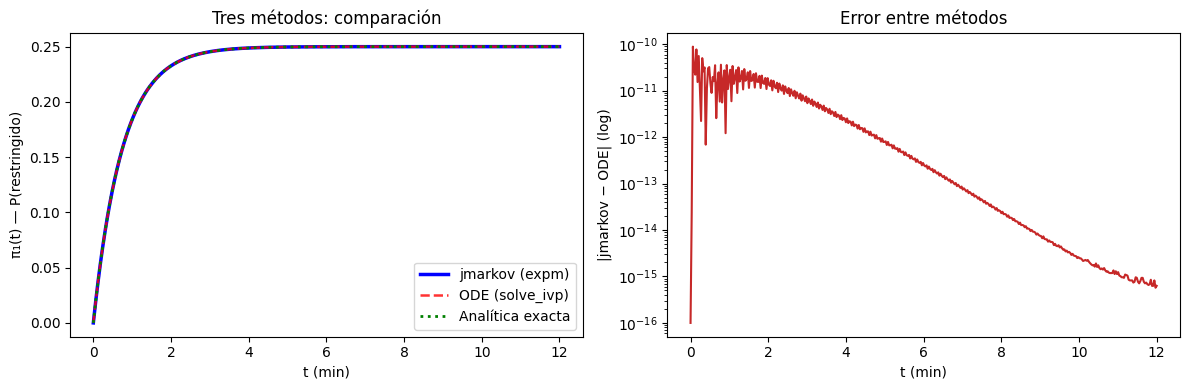

Error máximo jmarkov vs ODE: 8.86e-11


In [2]:
from scipy.integrate import solve_ivp

# Comparación jmarkov (expm) vs ODE numérica sobre el semáforo
def kolmogorov(t, pi_flat, Q):
    return (pi_flat.reshape(1,-1) @ Q).flatten()

sol = solve_ivp(kolmogorov, (0, 12), pi0_sem, args=(Q_sem,),
                dense_output=True, max_step=0.05)
t_ode = np.linspace(0, 12, 400)
pi_ode = sol.sol(t_ode).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_arr, pi_jm[:, 1], 'b-', lw=2.5, label='jmarkov (expm)')
axes[0].plot(t_ode, pi_ode[:, 1], 'r--', lw=1.8, alpha=0.8, label='ODE (solve_ivp)')
axes[0].plot(t_arr, pi1_analitica, 'g:', lw=2, label='Analítica exacta')
axes[0].set_xlabel('t (min)'); axes[0].set_ylabel('π₁(t) — P(restringido)')
axes[0].set_title('Tres métodos: comparación'); axes[0].legend()

err = np.abs(pi_jm[:, 1] - pi_ode[:, 1])
axes[1].semilogy(t_arr, err + 1e-16, color='#C62828', lw=1.5)
axes[1].set_xlabel('t (min)'); axes[1].set_ylabel('|jmarkov − ODE| (log)')
axes[1].set_title('Error entre métodos')
plt.tight_layout(); plt.show()
print(f"Error máximo jmarkov vs ODE: {err.max():.2e}")

## Ejercicio 1 — Instalación con 4 máquinas y 2 técnicos
<div class='defn'>
Una instalación tiene <strong>4 máquinas</strong> y <strong>2 trabajadores de reparación</strong>. Las máquinas fallan individualmente en media cada <strong>10 horas</strong> (α = 0.1/h). Un operario tarda en media <strong>4 horas</strong> en reparar (β = 0.25/h). Los tiempos de fallo y reparación son exponenciales independientes.
</div>

**Variable:** F(t) = número de máquinas dañadas, S = {0,1,2,3,4}

**Forma implícita:** λ_f = (4−f)·0.1, μ_f = min(f,2)·0.25

**Preguntas:**
- **(a)** ¿Cuál es la probabilidad de que exactamente la mitad de las máquinas esté dañada en 1 mes (720 h), si el sistema arranca con todas funcionando?
- **(b)** ¿Cuál es el valor esperado del número de máquinas funcionando en **3 meses** (2160 h)?

Matriz Q (f = # máquinas dañadas):
  F=0: [-0.4  0.4  0.   0.   0. ]
  F=1: [ 0.25 -0.55  0.3   0.    0.  ]
  F=2: [ 0.   0.5 -0.7  0.2  0. ]
  F=3: [ 0.   0.   0.5 -0.6  0.1]
  F=4: [ 0.   0.   0.   0.5 -0.5]


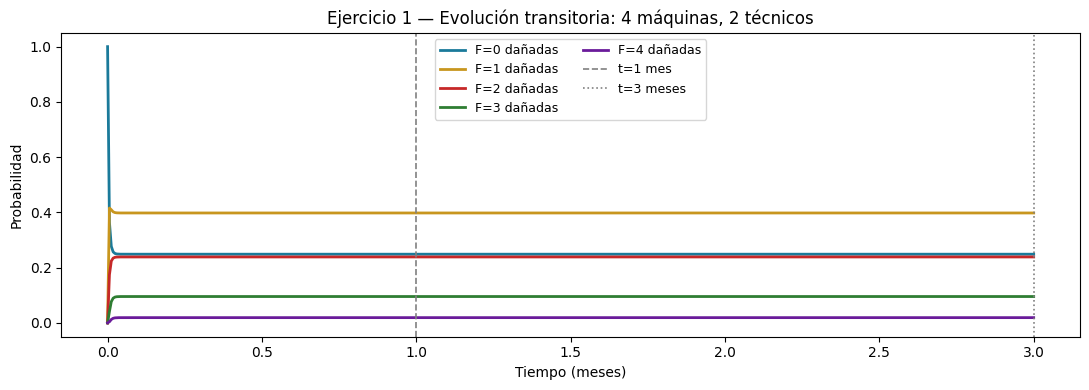


─── Respuestas ──────────────────────────────────────────────
(a) P(F=2 dañadas en t=1 mes=720h): 0.2388 = 23.88%

(b) π(t=3 meses=2160h): [0.2487 0.3979 0.2388 0.0955 0.0191]
    E[máquinas funcionando] = Σ(4-f)·π_f = 2.7616

    Estado estable π∞ (referencia):  [0.2487 0.3979 0.2388 0.0955 0.0191]
    E[máquinas funcionando en π∞] = 2.7616


In [3]:
M_maq, R_tec, alpha_m, beta_m = 4, 2, 0.1, 0.25

# Construcción de Q (modelo implícito)
Q_ej1 = np.zeros((M_maq+1, M_maq+1))
for f in range(M_maq+1):
    lf = (M_maq - f) * alpha_m
    mf = min(f, R_tec) * beta_m
    if f < M_maq: Q_ej1[f, f+1] = lf
    if f > 0:     Q_ej1[f, f-1] = mf
np.fill_diagonal(Q_ej1, -Q_ej1.sum(axis=1))

print("Matriz Q (f = # máquinas dañadas):")
estados_ej1 = np.array([f'F={f}' for f in range(M_maq+1)])
for i in range(M_maq+1):
    print(f"  {estados_ej1[i]}: {Q_ej1[i].round(3)}")

mc_ej1 = ctmc(Q_ej1, estados_ej1)
pi0_ej1 = np.array([1.0, 0., 0., 0., 0.])   # arranca con todas funcionando

# Trayectorias hasta 3 meses
t_mes = np.linspace(0, 2160, 500)
pi_traj = np.array([mc_ej1.transient_probabilities(t, pi0_ej1) for t in t_mes])

# Respuestas
pi_1mes = mc_ej1.transient_probabilities(720.0, pi0_ej1)
pi_3mes = mc_ej1.transient_probabilities(2160.0, pi0_ej1)
E_op_3m = sum((M_maq-f)*pi_3mes[f] for f in range(M_maq+1))

colors_ej = ['#1A7A9A','#C8961E','#C62828','#2E7D32','#6A1B9A']
fig, ax = plt.subplots(figsize=(11, 4))
for f in range(M_maq+1):
    ax.plot(t_mes/720, pi_traj[:,f], color=colors_ej[f], lw=2,
            label=f'F={f} dañadas')
ax.axvline(1, ls='--', color='gray', lw=1.2, label='t=1 mes')
ax.axvline(3, ls=':', color='gray', lw=1.2, label='t=3 meses')
ax.set_xlabel('Tiempo (meses)'); ax.set_ylabel('Probabilidad')
ax.set_title('Ejercicio 1 — Evolución transitoria: 4 máquinas, 2 técnicos')
ax.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()

print(f"\n─── Respuestas ──────────────────────────────────────────────")
print(f"(a) P(F=2 dañadas en t=1 mes=720h): {pi_1mes[2]:.4f} = {pi_1mes[2]*100:.2f}%")
print(f"\n(b) π(t=3 meses=2160h): {pi_3mes.round(4)}")
print(f"    E[máquinas funcionando] = Σ(4-f)·π_f = {E_op_3m:.4f}")
pi_inf_ej1 = mc_ej1.steady_state()
print(f"\n    Estado estable π∞ (referencia):  {pi_inf_ej1.round(4)}")
print(f"    E[máquinas funcionando en π∞] = {sum((M_maq-f)*pi_inf_ej1[f] for f in range(M_maq+1)):.4f}")

## Conclusiones
- El análisis transitorio responde **cuándo** y **cómo** el sistema llega al estado estable.
- La solución exacta es π(t) = π(0)·e^{Qt}; `jmarkov` lo evalúa internamente con `transient_probabilities(t, π₀)`.
- La **velocidad de convergencia** la determina el segundo valor propio de Q: λ₂ = −(λ+μ) para 2 estados.
- El **semáforo**: en solo 6 minutos ya alcanza el 95% del estado estable (λ+μ = 4/3 min⁻¹ es rápido).
- El **ejercicio de máquinas**: convergencia muy lenta (tasas pequeñas), por eso a 1 mes aún no está en estado estable.
- El **Metro de Bogotá**: la estación Caracas con trenes cada 25 min y λ=15.55/min se satura rápidamente → P(llena) alta.

**Próximo tema:** Estado estable — balance detallado, cadenas de nacimiento-muerte, colas M/M/1 y M/M/c.

## Ejercicio 3 — Metro de Bogotá
<div class='defn'>
La Primera Línea del Metro contará con 16 estaciones. Las 3 de mayor afluencia son:

| Estación | Capacidad | Tiempo trenes (min) | Llegadas (min⁻¹) |
|----------|-----------|---------------------|-------------------|
| Av. 1° de Mayo / Av. Boyacá | 57 | 4 | λ=11.94 |
| Av. NQS / diagonal 16 sur | 256 | 4 | λ=8.96 |
| Av. Caracas entre calles 24A y 26 | 213 | 25 | λ=15.55 |
</div>

Los trenes tienen capacidad máxima de 180 pasajeros. Si hay más de 180 esperando, el tren solo lleva 180. Los usuarios que no caben esperan al siguiente tren.

**Modelo:** cada estación es una CMTC M/M/1/K con K = capacidad, μ = 1/(tiempo entre trenes).

**Preguntas:**
- Para cada estación: E[usuarios] y Var[usuarios] durante la **primera hora** (arranca vacía)
- P(completamente ocupada) en el largo plazo

Estación               E[N](t=60)     Var[N](t=60)   P(llena) π∞
-----------------------------------------------------------------


Av. 1° de Mayo         56.98          0.02           0.9791


Av. NQS                255.97         0.03           0.9721


Av. Caracas            213.00         0.00           0.9974


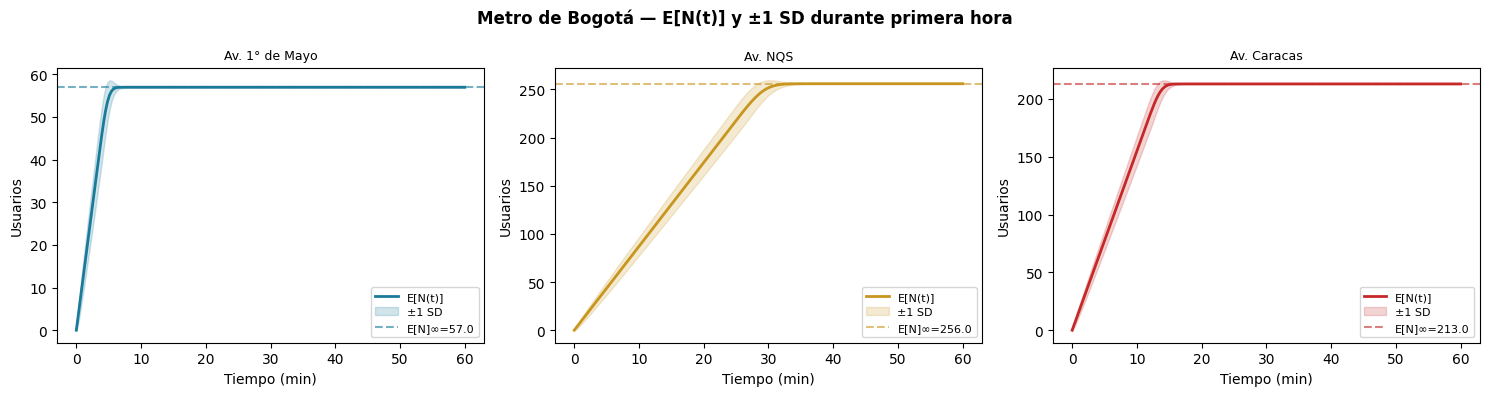

In [4]:
from scipy.integrate import solve_ivp

# Datos de cada estación
estaciones = {
    'Av. 1° de Mayo':  {'K': 57,  'T_tren': 4,  'lam': 11.94},
    'Av. NQS':         {'K': 256, 'T_tren': 4,  'lam': 8.96 },
    'Av. Caracas':     {'K': 213, 'T_tren': 25, 'lam': 15.55},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_est = ['#1A7A9A', '#C8961E', '#C62828']

print(f"{'Estación':<22} {'E[N](t=60)':<14} {'Var[N](t=60)':<14} {'P(llena) π∞'}")
print("-" * 65)

for ax, (nombre, d), col in zip(axes, estaciones.items(), colors_est):
    K   = d['K']
    mu  = 1 / d['T_tren']      # trenes/min
    lam = d['lam']

    # Construir Q para M/M/1/K
    Q_m = np.zeros((K+1, K+1))
    for n in range(K+1):
        if n < K: Q_m[n, n+1] = lam
        if n > 0: Q_m[n, n-1] = mu
    np.fill_diagonal(Q_m, -Q_m.sum(axis=1))

    mc_m  = ctmc(Q_m, np.arange(K+1))
    pi0_m = np.zeros(K+1); pi0_m[0] = 1.0   # arranca vacía

    # Análisis transitorio: E[N(t)] y Var[N(t)] durante 1 hora
    t_vals = np.linspace(0, 60, 200)
    E_t    = np.zeros(len(t_vals))
    Var_t  = np.zeros(len(t_vals))
    for i, t in enumerate(t_vals):
        pi_t = mc_m.transient_probabilities(t, pi0_m)
        E_t[i]   = sum(n * pi_t[n] for n in range(K+1))
        Var_t[i] = sum(n**2 * pi_t[n] for n in range(K+1)) - E_t[i]**2

    # Estado estacionario
    pi_inf_m = mc_m.steady_state()
    p_llena  = pi_inf_m[K]
    E_inf    = sum(n * pi_inf_m[n] for n in range(K+1))

    ax.plot(t_vals, E_t, color=col, lw=2, label='E[N(t)]')
    ax.fill_between(t_vals, E_t - np.sqrt(Var_t), E_t + np.sqrt(Var_t),
                    alpha=0.2, color=col, label='±1 SD')
    ax.axhline(E_inf, ls='--', color=col, alpha=0.6, label=f'E[N]∞={E_inf:.1f}')
    ax.set_xlabel('Tiempo (min)'); ax.set_ylabel('Usuarios')
    ax.set_title(nombre[:20], fontsize=9); ax.legend(fontsize=8)

    print(f"{nombre:<22} {E_t[-1]:<14.2f} {Var_t[-1]:<14.2f} {p_llena:.4f}")

plt.suptitle('Metro de Bogotá — E[N(t)] y ±1 SD durante primera hora', fontweight='bold')
plt.tight_layout(); plt.show()